# Card-Interpretation Evals

Runs the **production agent harness** (`agent.runtime.run_agent`) over a benchmark and measures: tool calls, answer similarity to the human canonical, executability, the *did-something* (no-op) rate, cost, and latency.

The harness reproduces real play: a live parity `GameState`, an actor who is **not** the card's author, the production toolbox (optionally filtered), the honored caps, and vision when enabled.

**Setup:** `uv sync --group evals`, select this repo's venv as the kernel, and configure the LLM gateway (`LLM_API_KEY` / `LLM_BASE_URL`) — the agent and the judge both call it.

Workflow: **1) Configure → 2) Run (auto-persists) → 3) Load history → 4) Compare → 5) Drill down.**

## Metric definitions

**LLM-judge scorers** (0–1, scored by a second model reading the card text and the generated effect; only when `use_judge=True`):

- `intent_match` — does the generated effect do what the card text asks?
- `target_accuracy` — does the effect hit the right target (self vs a chosen player vs everyone)?
- `persistence_accuracy` — is a one-shot effect one-shot, and an ongoing rule an ongoing rule with the right trigger?
- `magnitude_sign` — is the direction of the effect right (helps who it should help, hurts who it should hurt)?

**Deterministic scorers** (no LLM involved):

- `dsl_validity` — the plan is non-empty and every snippet/hook passes static sandbox validation.
- `executability` — the emitted plan compiles and dry-runs without error. Note: it doesn't look at the verdict, so even the agent's error-fallback plan (a single note op) passes — by design; see the callout below.
- `did_something` — the verdict isn't `invalid` AND the dry-run is clean AND at least one *mechanical* (non-note) op is emitted. This is the "did the card actually affect the game" check.
- `sandbox_behavior` — similarity of the ops the plan produces vs the expected ops on canned fixtures (1.0 when a card has no expected sandbox).

**Run-level aggregates** (in the summary table):

- `invalid_rate` — fraction of cards where the final verdict was `invalid`, whether the agent judged the card uninterpretable or fell back after an error.
- `agent_error_rate` — fraction of cards where the agent *crashed, timed out, or failed to parse its own answer* and returned the bounded fallback. High values mean the run is measuring infrastructure failures, not card interpretation.
- `consistency` — only when `n_samples > 1`: within-card score stability across samples (lower stdev = more deterministic agent).
- Plus cost/latency/token/tool-call stats (`mean_cost_usd`, `p50_latency_ms`, `mean_tool_calls`, …).

> **Reading divergence:** high `executability` with low `did_something` (or high `invalid_rate` / `agent_error_rate`) does **not** mean good plans — it means the agent is erroring into fallback no-op plans that trivially "execute". Check the run log for gateway errors (e.g. HTTP 402 `budget_exceeded`) before trusting any other metric.

In [1]:
import logging
import sys
from datetime import datetime
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))  # make src/ importable from scripts/

import matplotlib.pyplot as plt

from config import EVAL_BENCHMARKS, EVAL_MODEL_PRICES
from evals import store, viz
from evals.runner import EvalConfig, available_tool_names, run_benchmark

logging.basicConfig(level=logging.INFO, format="%(message)s")
logging.getLogger("evals.runner").setLevel(logging.INFO)

## 0. Initialise the RAG store

The `card_rag` tool needs the in-memory vector store seeded once per kernel (production does this in the FastAPI startup hook; the notebook has to do it itself, otherwise every `card_rag` call logs `retrieval unavailable ... call init_store() first`). Safe to re-run — it recreates the collection — and cheap thanks to the on-disk embedding cache (`.embedding_cache.json`). Skip this cell if your run's `enabled_tools` excludes `card_rag`.

**Caveat:** the store holds the full seed deck (gold + fillers), so on the `seed` benchmark `card_rag` can retrieve an eval card's own canonical. This mirrors production (seed cards live in the store there too), but keep it in mind when reading `seed` scores.

In [2]:
from agent.rag.seed import load_seed_cards

# Explicit path: the notebook's CWD is scripts/, and load_seed_cards' default
# data/seed_cards.json is CWD-relative, so the default would miss the file.
n = load_seed_cards(Path.cwd().parent / "data" / "seed_cards.json")
print(f"RAG store seeded with {n} cards")

HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/embeddings "HTTP/1.1 200 OK"
Loaded 131 seed cards into RAG store


RAG store seeded with 131 cards


## 1. Configure a run

Every knob on `EvalConfig`:

| Knob | Meaning |
|---|---|
| `benchmark` | `seed` / `eval` / `eval_hard` / `real` |
| `model_name` | chat model id; `None` = configured `LLM_CHAT_MODEL` |
| `enabled_tools` | `None` = full production toolbox; a `frozenset` of names from `TOOLS` below; `frozenset()` = no tools |
| `max_tool_calls` | agent step cap (production default 24); `None` = default |
| `timeout` | wall-clock seconds per card; `None` = default (600) |
| `vision` | attach card art / alt_text as an image (needs a vision model) |
| `n_samples` | samples per card; `>1` adds a consistency (stochastic reliability) metric |
| `sample_size` | cap cards per benchmark; `None` = all (**set one for `real`** — 698 cards) |
| `concurrency` | cards run in parallel threads; 4–8 is a good speedup for big runs |
| `use_judge` | run the LLM judge (costs money) vs deterministic scorers only |
| `tracing` | LangSmith tracing during the run; `False` (default) suppresses it to save costs, `True` inherits the ambient `LANGSMITH_TRACING` setting |
| `label` | short name shown in charts |

In [3]:
TOOLS = available_tool_names()

print("Benchmarks: ", ", ".join(f"{name} ({spec['path']})" for name, spec in EVAL_BENCHMARKS.items()))
print("Tools:      ", ", ".join(TOOLS))
print("Prices ($/1M tokens):", EVAL_MODEL_PRICES)

Benchmarks:  seed (data/seed_cards.json), eval (data/eval/eval_cards.json), eval_hard (data/eval/eval_cards_hard.json), real (data/eval/real_cards.json)
Tools:       card_rag_hybrid, dry_run_effect, game_rules, mtg_lookup, read_engine_methods, read_game_history, read_game_state, recall_decisions, remember_decision, web_search
Prices ($/1M tokens): {'us.anthropic.claude-haiku-4-5-20251001-v1:0': {'input': 1.0, 'output': 5.0}, 'claude-haiku-4-5': {'input': 1.0, 'output': 5.0}, 'claude-haiku-4-5-20251001': {'input': 1.0, 'output': 5.0}, 'us.anthropic.claude-sonnet-5': {'input': 3.0, 'output': 15.0}, 'claude-sonnet-5': {'input': 3.0, 'output': 15.0}, 'us.anthropic.claude-opus-4-8': {'input': 5.0, 'output': 25.0}, 'claude-opus-4-8': {'input': 5.0, 'output': 25.0}, 'google.gemma-4-31b': {'input': 0.14, 'output': 0.4}, 'openai.gpt-5.4': {'input': 2.75, 'output': 16.5}, 'default': {'input': 0.5, 'output': 1.5}}


In [4]:
config = EvalConfig(
    benchmark="seed",
    model_name="us.anthropic.claude-haiku-4-5-20251001-v1:0",  # e.g. "us.anthropic.claude-haiku-4-5-20251001-v1:0" or "openai.gpt-5.4"
    # Retrieval A/B (Task 6): arms differ only in which card-RAG tool is exposed.
    # Dense arm: frozenset(TOOLS) - {"card_rag_hybrid"}; hybrid arm: frozenset(TOOLS) - {"card_rag"}.
    # enabled_tools=frozenset(TOOLS) - {"card_rag"},
    enabled_tools=None,  # None = all tools enabled
    max_tool_calls=None,  # Default is 12
    timeout=None,
    vision=False,
    n_samples=1,
    sample_size=None,  # small while iterating; None for the full set
    concurrency=5,
    use_judge=True,
    tracing=False,
    label="haiku - new seed 2",
)
config

EvalConfig(benchmark='seed', model_name='us.anthropic.claude-haiku-4-5-20251001-v1:0', enabled_tools=None, allow_persistent_tools=False, max_tool_calls=None, timeout=None, vision=False, n_samples=1, sample_size=None, concurrency=5, use_judge=True, tracing=False, prices=None, label='haiku - new seed 2')

## 2. Run it

Expect roughly `cards x n_samples x per-card latency / concurrency`. The run is written to `data/eval/runs/<timestamp>_<benchmark>_<model>.json`, so it survives kernel restarts and can be compared later.

In [5]:
run = run_benchmark(config, timestamp=datetime.now().strftime("%Y%m%d-%H%M%S"))
print("saved:", store.save_run(run))
viz.summary_table([run.aggregate()])

HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://dev.llm.cloud.flexion.us/openai/c

saved: /Users/msharp/projects/a-thousand-blank-white-cards/data/eval/runs/20260722-204747_seed_us-anthropic-claude-haiku-4-5-20251001-v1-0.json


,label,benchmark,model,cases,n_samples,intent_match,target_accuracy,persistence_accuracy,magnitude_sign,sandbox_behavior,executability,did_something,mean_tool_calls,mean_cost_usd,total_cost_usd,p50_latency_ms,p95_latency_ms,invalid_rate
0,haiku - new seed 2,seed,us.anthropic.claude-haiku-4-5-20251001-v1:0,131,1,0.810687,0.818321,0.88855,0.880916,0.719466,0.992366,0.862595,4.335878,0.0339,4.44096,10794.851625,30231.457125,0.068702


## 3. Load run history

Loads **every** persisted run in chronological order; slice `payloads` (or pass explicit paths) to compare a subset.

In [6]:
payloads = store.load_runs()  # or store.load_runs([Path("data/eval/runs/....json"), ...])
summaries = [p["summary"] for p in payloads]
print(f"{len(summaries)} run(s) loaded")
viz.summary_table(summaries)

23 run(s) loaded


,label,benchmark,model,cases,n_samples,intent_match,target_accuracy,persistence_accuracy,magnitude_sign,sandbox_behavior,executability,did_something,mean_tool_calls,mean_cost_usd,total_cost_usd,p50_latency_ms,p95_latency_ms,invalid_rate
0,sonnet - eval,eval,us.anthropic.claude-sonnet-5,42,1,0.876190,0.794048,0.780952,0.942857,0.428571,0.928571,0.857143,5.142857,0.153329,6.439818,15681.713875,90029.969583,0.047619
1,sonnet - seed,seed,us.anthropic.claude-sonnet-5,69,1,0.860870,0.784058,0.786957,0.931884,0.564010,0.884058,0.739130,6.043478,0.185329,12.787692,24020.278667,124388.073333,0.072464
2,sonnet - eval_hard,eval_hard,us.anthropic.claude-sonnet-5,25,1,0.950000,0.924000,0.960000,1.000000,0.633333,1.000000,0.760000,7.200000,0.221733,5.543322,26242.006666,86470.030000,0.000000
3,haiku - eval,eval,us.anthropic.claude-haiku-4-5-20251001-v1:0,42,1,0.828571,0.690476,0.695238,0.897619,0.371032,0.857143,0.857143,4.404762,0.032887,1.381247,9172.193333,29403.307583,0.071429
4,haiku - seed,seed,us.anthropic.claude-haiku-4-5-20251001-v1:0,69,1,0.736232,0.652174,0.673913,0.817391,0.317633,0.826087,0.768116,5.623188,0.047546,3.280704,11635.928583,44797.855334,0.086957
5,haiku - eval_hard,eval_hard,us.anthropic.claude-haiku-4-5-20251001-v1:0,25,1,0.852000,0.840000,0.844000,0.856000,0.493333,0.880000,0.760000,4.960000,0.038319,0.957984,11449.829542,31117.162542,0.040000
6,opus - eval,eval,us.anthropic.claude-opus-4-8,42,1,0.826190,0.754762,0.804762,0.964286,0.426587,0.952381,0.928571,2.976190,0.135458,5.689240,10794.838834,30306.891875,0.023810
7,opus - seed,seed,us.anthropic.claude-opus-4-8,69,1,0.815942,0.751449,0.785507,0.902899,0.422705,0.956522,0.797101,3.521739,0.173017,11.938195,13927.345708,43513.502083,0.043478
8,opus - eval_hard,eval_hard,us.anthropic.claude-opus-4-8,25,1,0.852000,0.860000,0.880000,0.860000,0.593333,0.880000,0.680000,4.080000,0.176203,4.405070,12749.773083,37688.559917,0.120000
9,gemma - eval,eval,google.gemma-4-31b,42,1,0.505952,0.459524,0.450000,0.566667,0.410714,0.761905,0.500000,3.500000,0.004939,0.207449,3213.092625,82337.686417,0.428571


## 4. Compare runs

Each run keeps one color across every chart. Higher is better for the quality metrics; lower is better for tool calls, cost, and latency.

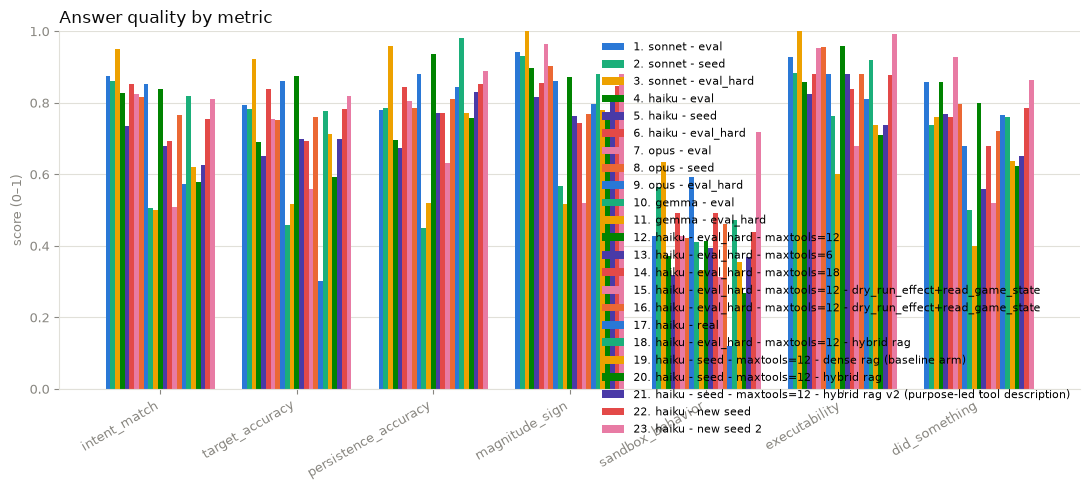

In [7]:
viz.plot_quality(summaries)
plt.tight_layout()
plt.show()

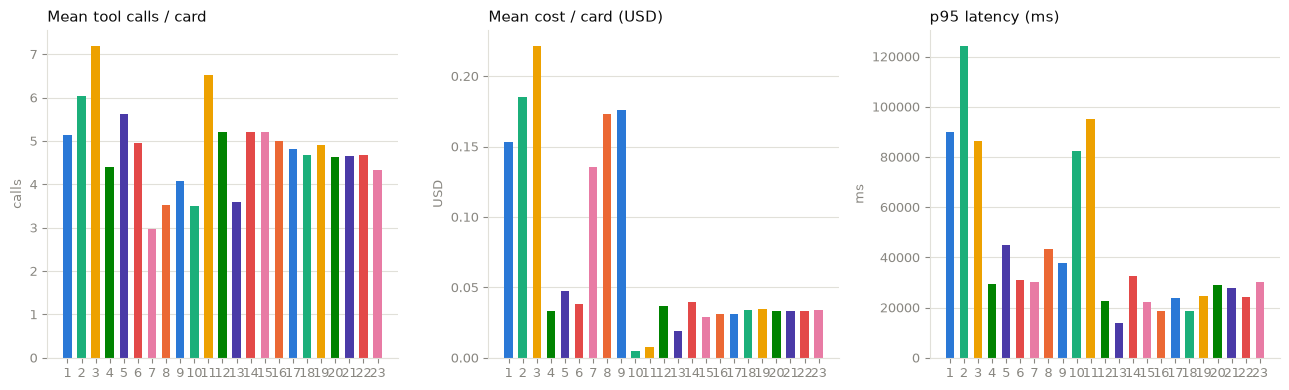

In [8]:
viz.plot_efficiency(summaries)
plt.tight_layout()
plt.show()

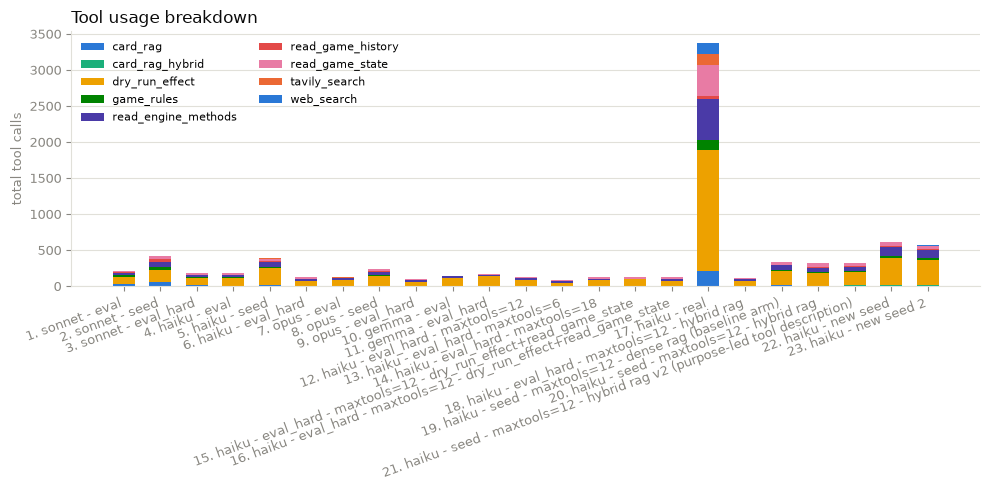

In [9]:
viz.plot_tool_usage(summaries)
plt.tight_layout()
plt.show()

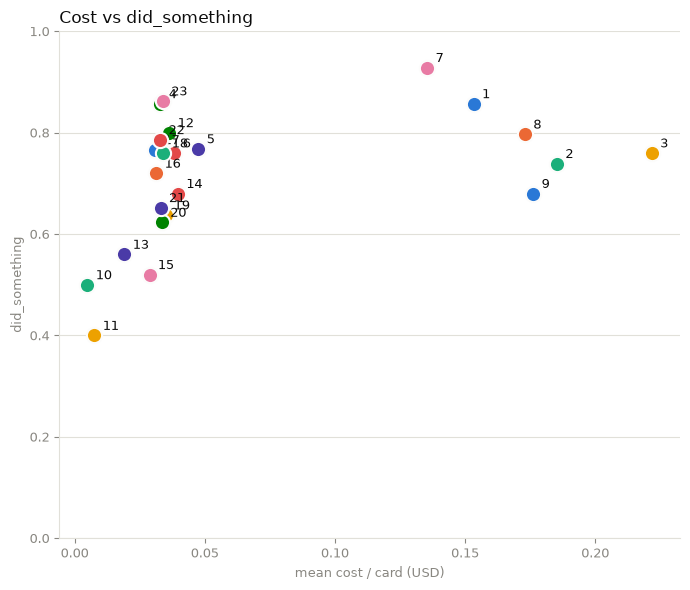

In [10]:
viz.plot_cost_vs_quality(summaries, quality_key="did_something")
plt.tight_layout()
plt.show()

## 5. Drill down: worst cards

The lowest-scoring cards for a chosen metric in one run, with the failure reason — where to look when a metric drops. Try `metric="intent_match"`, `"executability"`, `"sandbox_behavior"`, or `"did_something"`.

In [11]:
viz.worst_cards(payloads[-1], metric="executability", n=10)

,card_id,title,verdict,executability,reason
81,seed-filler-022,Choose Your Destiny,invalid,0.0,no executable plan
95,seed-filler-036,Nap Time,ok,1.0,The generated effect sets the napping conditio...
94,seed-filler-035,The Hype Card,ok,1.0,The generated effect correctly implements the ...
93,seed-filler-034,Legacy Card,ok,1.0,The generated effect fundamentally misundersta...
92,seed-filler-033,Unreliable Narrator,ok,1.0,The generated effect completely misinterprets ...
91,seed-filler-032,Hot Potato,ok,1.0,The generated effect correctly identifies the ...
90,seed-filler-031,The Bystander,ok,1.0,The generated effect perfectly captures the ca...
89,seed-filler-030,Timeout,ok,1.0,The generated effect correctly captures the ca...
88,seed-filler-029,The Clone,ok,1.0,The generated effect misinterprets the card's ...
87,seed-filler-028,Two Truths and a Lie (Card Edition),invalid,1.0,The generated effect completely failed to inte...
